# Projeto Final: RideSmart
## Modelagem e Análise de Rotas Urbanas com Grafos
**Integrantes:** Eugenio Vitor Lopes dos Santos, Lucas Augusto da Silva Cardoso, Pedro Henrique Ribeiro de Lima


### Resumo do problema

Dado um ponto de origem `A`, um destino `B` e uma distância máxima de caminhada `X`, o objetivo é
escolher um **ponto de embarque** `P` (a no máximo `X` metros de caminhada de `A`) que minimize o
custo total da viagem, composta por dois trechos:

```text
A → P   (a pé)
P → B   (de carro)
```

O notebook modela a malha viária real como grafo, implementa e compara quatro algoritmos de caminho
mínimo, introduz **trânsito sintético** e analisa o *trade-off* entre caminhar um pouco e chegar
mais rápido.

## 1. Modelagem do problema como grafo

**Grafo dirigido com multiarestas** $G = (V, E)$ obtido do OpenStreetMap via OSMnx:

- **Nós ($V$):** cruzamentos e extremidades de vias. Cada nó possui coordenadas geográficas
  (`y` = latitude, `x` = longitude).
- **Arestas ($E$):** segmentos de rua entre dois cruzamentos. O grafo é um `MultiDiGraph`:
  é **dirigido** (modela ruas de mão única) e admite **arestas paralelas** (duas ruas distintas
  ligando o mesmo par de cruzamentos).

**Funções de custo (pesos das arestas):**

| Peso | Significado | Usado para |
|---|---|---|
| `length` | comprimento do segmento em metros | menor **distância** e caminhada `A→P` |
| `travel_time` | tempo de percurso de carro em segundos (sem trânsito) | rota mais **rápida** |
| `travel_time_traffic` | `travel_time` ajustado por um fator de congestionamento | rota mais rápida **com trânsito** |

O tempo de caminhada é derivado do comprimento por uma velocidade fixa de pedestre
($v_{pe} \approx 1{,}4$ m/s $\approx 5$ km/h):
$$t_{pe}(A \to P) = \frac{\text{distância}_{length}(A \to P)}{v_{pe}}.$$

O **custo total** de uma escolha de embarque `P` é:
$$\text{custo}(P) = t_{pe}(A \to P) + \text{custo}_{carro}(P \to B),$$
sujeito à restrição $\text{distância}_{length}(A \to P) \le X$.

## 2. Configuração do ambiente

Em ambientes como o Google Colab, descomente a instalação abaixo. O OSMnx requer acesso à internet
para baixar os dados do OpenStreetMap.

In [1]:
%pip install osmnx networkx pandas matplotlib scikit-learn numpy 

import time
import copy
import math
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
from IPython.display import display
import plotly.graph_objects as go
import ast
from matplotlib.animation import FuncAnimation, PillowWriter

ox.settings.use_cache = True          # cacheia o download (re-execuções ficam instantâneas)
ox.settings.log_console = False
print("OSMnx", ox.__version__, "| NetworkX", nx.__version__)

Note: you may need to restart the kernel to use updated packages.
OSMnx 2.1.0 | NetworkX 3.6.1


## 3. Download da malha viária real

Baixamos a rede **dirigível** (`network_type="drive"`) num raio em torno de um ponto central da
cidade. Em seguida o OSMnx imputa velocidades por tipo de via (`add_edge_speeds`) e calcula o tempo
de percurso de cada aresta (`add_edge_travel_times`).

In [2]:
# Centro da área de estudo (exemplo: bairro de Petrópolis / Tirol, Natal-RN).
CENTRO = (-5.8000, -35.2050)   # (lat, lon)
RAIO_M = 2500                  # raio da malha em metros

G = ox.graph_from_point(CENTRO, dist=RAIO_M, network_type="drive")

# velocidades (km/h) e tempos de percurso (s) por aresta
try:
    G = ox.routing.add_edge_speeds(G)
    G = ox.routing.add_edge_travel_times(G)
except AttributeError:                 # compatibilidade com versões antigas
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)

print(f"[drive] Nós: {G.number_of_nodes()}  |  Arestas: {G.number_of_edges()}")
u, v, k, d = list(G.edges(keys=True, data=True))[0]
print(f"  Aresta exemplo: {d.get('name')} | length={d.get('length'):.1f}m | travel_time={d.get('travel_time'):.1f}s")

# Grafo separado para caminhada (inclui calçadas e vias de pedestre)
G_walk = ox.graph_from_point(CENTRO, dist=RAIO_M, network_type="walk")
print(f"[walk]  Nós: {G_walk.number_of_nodes()}  |  Arestas: {G_walk.number_of_edges()}")

[drive] Nós: 3104  |  Arestas: 6762
  Aresta exemplo: Avenida Governador Sílvio Pedroza | length=28.2m | travel_time=1.9s
[walk]  Nós: 4932  |  Arestas: 14462


## 4. Definição de origem `A`, destino `B`, distância máxima `X`

Escolhemos coordenadas reais de `A` e `B` e mapeamos cada uma para o nó mais próximo da malha
(`nearest_nodes`). `X` é a distância máxima que o usuário aceita caminhar; `V_PE` é a velocidade de
caminhada.

In [3]:
# Coordenadas de origem e destino (lat, lon)
A_latlon = (-5.7935, -35.2010)
B_latlon = (-5.8120, -35.1980)

X      = 600.0    # distância máxima de caminhada (metros)
V_PE   = 1.4      # velocidade de caminhada (m/s) ~ 5 km/h

A = ox.distance.nearest_nodes(G, A_latlon[1], A_latlon[0])
B = ox.distance.nearest_nodes(G, B_latlon[1], B_latlon[0])
A_walk = ox.distance.nearest_nodes(G_walk, A_latlon[1], A_latlon[0])
print(f"Nó de origem  A = {A}  (walk: {A_walk})")
print(f"Nó de destino B = {B}")

# velocidade máxima do grafo (m/s) — usada na heurística do A* para tempo
VMAX_MS = max(d.get('speed_kph', 1) for _,_,d in G.edges(data=True)) / 3.6
print(f"Velocidade máxima do grafo: {VMAX_MS*3.6:.0f} km/h")

Nó de origem  A = 8626298111  (walk: 7616423477)
Nó de destino B = 503422480
Velocidade máxima do grafo: 70 km/h


## 5. Implementação dos algoritmos

Nesta seção implementaremos os algoritmos de caminho mínimo usados neste notebook.

Cada algoritmo terá uma subseção própria com uma pequena descrição, análise assintótica e testes com pelo menos 2 pares de nós.

1. **Dijkstra simples**: implementação clássica com seleção linear do próximo vértice
2. **Dijkstra com fila de prioridade (heap)**: versão mais eficiente do Dijkstra
3. **Bellman-Ford**: algoritmo robusto que lida com arestas negativas
4. **A* geográfico**: usa heurística de distância geográfica para direcionar a busca

### 5.1 Dijkstra simples

O Dijkstra simples encontra caminhos mínimos em grafos com pesos não negativos.
Nesta versão, a escolha do próximo nó é feita por busca linear na coleção de não visitados,
o que torna a implementação direta e fácil de entender, porém menos eficiente em grafos grandes.

| Aspecto | Detalhe |
|---|---|
| Complexidade | $O(V^2)$ |
| Pesos negativos | Não suporta |
| Estrutura | Busca linear do próximo vértice |
| Uso aqui | Linha de base para comparação |

In [4]:

# Função que itera vizinhos com peso, considerando multigrafos
def vizinhos_ponderados(G, no, weight='travel_time'):
    # Para multigrafos, considera o menor peso entre as arestas paralelas
    if G.is_multigraph():
        for vizinho, arestas in G[no].items():
            menor_peso = float('inf')
            for data in arestas.values():
                menor_peso = min(menor_peso, data.get(weight, float('inf')))
            yield vizinho, menor_peso
    else:
        for vizinho, data in G[no].items(): 
            yield vizinho, data.get(weight, float('inf'))

# Função que reconstrói o caminho 
def reconstruir_caminho(prev, destino):
    caminho = []
    no = destino
    # Percorre o dicionário de predecessores até a origem
    while no is not None:
        caminho.append(no)  
        no = prev[no]  
    caminho.reverse() 
    return caminho

# Função que implementa o Dijkstra simples
def dijkstra_simples(G, origem, destino, weight='travel_time', track_history=False):
    t0 = time.perf_counter() 
    dist = {n: float('inf') for n in G.nodes()} 
    prev = {n: None for n in G.nodes()} 
    nao_visitados = set(G.nodes())
    dist[origem] = 0.0
    expandidos = 0
    hist = []

    # Seleciona o nó com menor distância e a atualiza os vizinhos
    while nao_visitados:
        atual = min(nao_visitados, key=lambda n: dist[n])
        if dist[atual] == float('inf'):
            break

        nao_visitados.remove(atual)
        expandidos += 1
        hist.append(atual)
        if atual == destino:
            break

        for vizinho, peso in vizinhos_ponderados(G, atual, weight):
            if vizinho in nao_visitados:
                novo_custo = dist[atual] + peso
                if novo_custo < dist[vizinho]:
                    dist[vizinho] = novo_custo
                    prev[vizinho] = atual

    caminho = []
    if dist[destino] < float('inf'):
        caminho = reconstruir_caminho(prev, destino)

    res = {
        'distancia': dist[destino],
        'caminho': caminho,
        'expandidos': expandidos,
        'ciclo_negativo': False,
        'tempo': time.perf_counter() - t0,
    }
    return (res, hist) if track_history else res

In [5]:
# Teste Dijkstra simples com 2 pares de nós
print("="*60)
print("DIJKSTRA SIMPLES — TESTES")
print("="*60)

nos_lista = list(G.nodes())
n2_orig = nos_lista[len(nos_lista) // 3]
n2_dest = nos_lista[2 * len(nos_lista) // 3]

pares = [
    ("Par 1", A, B),
    ("Par 2", n2_orig, n2_dest),
]

resultados_dijkstra = {}

for nome_par, origem, destino in pares:
    resultado = dijkstra_simples(G, origem, destino, weight='travel_time')
    resultados_dijkstra[nome_par] = resultado

    print(f"\n{nome_par}: {origem} → {destino}")
    print(f"  Distância: {resultado['distancia']:.1f}s")
    print(f"  Nós no caminho: {len(resultado['caminho'])}")
    print(f"  Expandidos: {resultado['expandidos']}")
    print(f"  Tempo: {resultado['tempo']*1000:.2f}ms")

DIJKSTRA SIMPLES — TESTES

Par 1: 8626298111 → 503422480
  Distância: 237.8s
  Nós no caminho: 38
  Expandidos: 1733
  Tempo: 204.92ms

Par 2: 526593101 → 5264901355
  Distância: 171.8s
  Nós no caminho: 22
  Expandidos: 753
  Tempo: 104.46ms


### 5.2 Dijkstra com fila de prioridade (heap)

Uma versão mais eficiente do Dijkstra usa uma fila de prioridade (`heap`) para selecionar o próximo nó com menor distância acumulada. Em vez de varrer todos os nós não visitados a cada passo, o algoritmo reduz o custo da escolha do próximo vértice.

| Aspecto | Detalhe |
|---|---|
| Complexidade | $O((V + E) \log V)$ |
| Estrutura | Fila de prioridade com `heapq` |
| Pesos negativos | Não suporta |
| Uso aqui | Comparar desempenho com o Dijkstra simples |

In [6]:

# Função que implementa o Dijkstra com fila de prioridade (heap)
def dijkstra_heap(G, origem, destino, weight='travel_time', track_history=False):
    t0 = time.perf_counter()
    dist = {n: float('inf') for n in G.nodes()}
    prev = {n: None for n in G.nodes()}
    dist[origem] = 0.0

    pq = [(0.0, origem)]
    fechado = set()
    expandidos = 0
    hist = []

    while pq:
        dist_atual, atual = heapq.heappop(pq)
        if atual in fechado:
            continue
        if dist_atual > dist[atual]:
            continue

        fechado.add(atual)
        expandidos += 1
        hist.append(atual)
        if atual == destino:
            break

        for vizinho, peso in vizinhos_ponderados(G, atual, weight):
            novo_custo = dist[atual] + peso
            if novo_custo < dist[vizinho]:
                dist[vizinho] = novo_custo
                prev[vizinho] = atual
                heapq.heappush(pq, (novo_custo, vizinho))

    caminho = []
    if dist[destino] < float('inf'):
        caminho = reconstruir_caminho(prev, destino)

    res = {
        'distancia': dist[destino],
        'caminho': caminho,
        'expandidos': expandidos,
        'ciclo_negativo': False,
        'tempo': time.perf_counter() - t0,
    }
    return (res, hist) if track_history else res

In [7]:
# Teste Dijkstra com heap usando os mesmos pares do Dijkstra simples
print("="*60)
print("DIJKSTRA COM HEAP — TESTES")
print("="*60)

pares_heap = [
    ("Par 1", A, B),
    ("Par 2", n2_orig, n2_dest),
]

resultados_dijkstra_heap = {}
comparacao_tempo_dijkstra = {}

for nome_par, origem, destino in pares_heap:
    resultado_heap = dijkstra_heap(G, origem, destino, weight='travel_time')
    resultados_dijkstra_heap[nome_par] = resultado_heap

    print(f"\n{nome_par}: {origem} → {destino}")
    print(f"  Distância: {resultado_heap['distancia']:.1f}s")
    print(f"  Nós no caminho: {len(resultado_heap['caminho'])}")
    print(f"  Expandidos: {resultado_heap['expandidos']}")
    print(f"  Tempo: {resultado_heap['tempo']*1000:.2f}ms")

    if 'resultados_dijkstra' in globals() and nome_par in resultados_dijkstra:
        resultado_simples = resultados_dijkstra[nome_par]
        tempo_simples = resultado_simples['tempo']
        tempo_heap = resultado_heap['tempo']
        delta_tempo = tempo_simples - tempo_heap
        reducao_pct = (delta_tempo / tempo_simples) * 100 if tempo_simples > 0 else 0.0

        comparacao_tempo_dijkstra[nome_par] = {
            'tempo_simples': tempo_simples,
            'tempo_heap': tempo_heap,
            'delta_tempo': delta_tempo,
            'reducao_pct': reducao_pct,
        }

        print(f"  Comparação com Dijkstra simples: {tempo_simples*1000:.2f}ms vs {tempo_heap*1000:.2f}ms")
        print(f"  Redução de tempo: {reducao_pct:.1f}%")

print("\nResumo da comparação de tempo armazenado em 'comparacao_tempo_dijkstra'.")

DIJKSTRA COM HEAP — TESTES

Par 1: 8626298111 → 503422480
  Distância: 237.8s
  Nós no caminho: 38
  Expandidos: 1733
  Tempo: 7.39ms
  Comparação com Dijkstra simples: 204.92ms vs 7.39ms
  Redução de tempo: 96.4%

Par 2: 526593101 → 5264901355
  Distância: 171.8s
  Nós no caminho: 22
  Expandidos: 753
  Tempo: 3.95ms
  Comparação com Dijkstra simples: 104.46ms vs 3.95ms
  Redução de tempo: 96.2%

Resumo da comparação de tempo armazenado em 'comparacao_tempo_dijkstra'.


### 5.3 Bellman-Ford

O Bellman-Ford calcula caminhos mínimos a partir de uma origem em grafos com arestas de peso
arbitrário, inclusive negativas. Ele realiza $V-1$ rodadas de relaxação sobre todas as arestas;
uma rodada extra detecta ciclos de peso negativo.

| Aspecto | Detalhe |
|---|---|
| Complexidade | $O(V \cdot E)$ |
| Grafos negativos | Suporta (diferente do Dijkstra) |
| Ciclos negativos | Detecta na iteração $V$ |
| Uso aqui | Base para comparação de desempenho |

In [8]:
def bellman_ford(G, origem, destino, weight='travel_time', track_history=False):
    t0 = time.perf_counter()

    dist = {n: float('inf') for n in G.nodes()}
    prev = {n: None for n in G.nodes()}
    dist[origem] = 0.0

    edges = [(u, v, d.get(weight, float('inf'))) for u, v, d in G.edges(data=True)]
    V = G.number_of_nodes()
    expandidos = 0
    hist = []

    for _ in range(V - 1):
        atualizou = False
        for u, v, w in edges:
            expandidos += 1
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                prev[v] = u
                hist.append(v)
                atualizou = True
        if not atualizou:
            break

    ciclo_negativo = False
    for u, v, w in edges:
        expandidos += 1
        if dist[u] + w < dist[v]:
            ciclo_negativo = True
            break

    caminho = []
    if dist[destino] < float('inf'):
        no = destino
        while no is not None:
            caminho.append(no)
            no = prev[no]
        caminho.reverse()

    t_total = time.perf_counter() - t0

    res = {
        'distancia': dist[destino],
        'caminho': caminho,
        'expandidos': expandidos,
        'ciclo_negativo': ciclo_negativo,
        'tempo': t_total,
    }
    return (res, hist) if track_history else res

In [9]:
# Teste Bellman-Ford com 2 pares de nós
print("="*60)
print("BELLMAN-FORD — TESTES")
print("="*60)

nos_lista = list(G.nodes())
n2_orig = nos_lista[len(nos_lista) // 3]
n2_dest = nos_lista[2 * len(nos_lista) // 3]

pares_bf = [
    ("Par 1", A, B),
    ("Par 2", n2_orig, n2_dest),
]

resultados_bellman = {}

for nome_par, origem, destino in pares_bf:
    resultado = bellman_ford(G, origem, destino, weight='travel_time')
    resultados_bellman[nome_par] = resultado

    print(f"\n{nome_par}: {origem} → {destino}")
    print(f"  Distância: {resultado['distancia']:.1f}s")
    print(f"  Nós no caminho: {len(resultado['caminho'])}")
    print(f"  Expandidos: {resultado['expandidos']}")
    print(f"  Ciclo negativo: {'SIM' if resultado['ciclo_negativo'] else 'NÃO'}")
    print(f"  Tempo: {resultado['tempo']*1000:.2f}ms")

BELLMAN-FORD — TESTES

Par 1: 8626298111 → 503422480
  Distância: 237.8s
  Nós no caminho: 38
  Expandidos: 297528
  Ciclo negativo: NÃO
  Tempo: 26.75ms

Par 2: 526593101 → 5264901355
  Distância: 171.8s
  Nós no caminho: 22
  Expandidos: 297528
  Ciclo negativo: NÃO
  Tempo: 26.24ms


### 5.4 A* geográfico

O algoritmo A* estende o Dijkstra adicionando uma heurística que estima o custo do nó atual até o destino.
Nesta versão, a heurística baseia-se na distância euclidiana geográfica calculada a partir das coordenadas de latitude e longitude.
Quando o peso de busca é baseado em tempo (`travel_time` ou `travel_time_traffic`), a distância em metros estimada é dividida pela velocidade máxima permitida no grafo para garantir a admissibilidade da heurística.

| Aspecto | Detalhe |
|---|---|
| Complexidade | $O((V + E) \log V)$ |
| Pesos negativos | Não suporta |
| Heurística | Distância euclidiana em metros (com ou sem divisão pela velocidade máxima) |
| Estrutura | Fila de prioridades (heap binário) |

In [10]:

def a_estrela(G, origem, destino, weight='travel_time', track_history=False):
    t0 = time.perf_counter()
    
    def h(u):
        lat1 = G.nodes[u]['y']
        lon1 = G.nodes[u]['x']
        lat2 = G.nodes[destino]['y']
        lon2 = G.nodes[destino]['x']
        dy = (lat1 - lat2) * 111000.0
        dx = (lon1 - lon2) * 111000.0 * math.cos(math.radians((lat1 + lat2) / 2.0))
        dist_metros = math.sqrt(dx**2 + dy**2)
        if weight == 'length':
            return dist_metros
        else:
            return dist_metros / VMAX_MS

    g_score = {n: float('inf') for n in G.nodes()}
    g_score[origem] = 0.0
    f_score = {n: float('inf') for n in G.nodes()}
    f_score[origem] = h(origem)
    pq = []
    heapq.heappush(pq, (f_score[origem], 0.0, origem))
    prev = {n: None for n in G.nodes()}
    fechados = set()
    expandidos = 0
    hist = []
    
    while pq:
        f_atual, g_atual, atual = heapq.heappop(pq)
        if atual in fechados:
            continue
        fechados.add(atual)
        expandidos += 1
        hist.append(atual)
        if atual == destino:
            break
        for vizinho, peso in vizinhos_ponderados(G, atual, weight):
            tentative_g = g_score[atual] + peso
            if tentative_g < g_score[vizinho]:
                prev[vizinho] = atual
                g_score[vizinho] = tentative_g
                f_score[vizinho] = tentative_g + h(vizinho)
                heapq.heappush(pq, (f_score[vizinho], tentative_g, vizinho))
                
    caminho = []
    if g_score[destino] < float('inf'):
        caminho = reconstruir_caminho(prev, destino)
        
    res = {
        'distancia': g_score[destino],
        'caminho': caminho,
        'expandidos': expandidos,
        'ciclo_negativo': False,
        'tempo': time.perf_counter() - t0,
    }
    return (res, hist) if track_history else res

In [11]:
# Teste A* geográfico com 2 pares de nós
print("="*60)
print("A* GEOGRÁFICO — TESTES")
print("="*60)

nos_lista = list(G.nodes())
n2_orig = nos_lista[len(nos_lista) // 3]
n2_dest = nos_lista[2 * len(nos_lista) // 3]

pares_astar = [
    ("Par 1", A, B),
    ("Par 2", n2_orig, n2_dest),
]

resultados_astar = {}

for nome_par, origem, destino in pares_astar:
    resultado = a_estrela(G, origem, destino, weight='travel_time')
    resultados_astar[nome_par] = resultado

    print(f"\n{nome_par}: {origem} → {destino}")
    print(f"  Distância: {resultado['distancia']:.1f}s")
    print(f"  Nós no caminho: {len(resultado['caminho'])}")
    print(f"  Expandidos: {resultado['expandidos']}")
    print(f"  Tempo: {resultado['tempo']*1000:.2f}ms")
    
    # Comparação direta de nós expandidos se o Dijkstra simples tiver dados para esse par
    if 'resultados_dijkstra' in globals() and nome_par in resultados_dijkstra:
        dij_exp = resultados_dijkstra[nome_par]['expandidos']
        diff_pct = ((dij_exp - resultado['expandidos']) / dij_exp) * 100 if dij_exp > 0 else 0
        print(f"  Comparação com Dijkstra: A* expandiu {resultado['expandidos']} vs Dijkstra {dij_exp} (redução de {diff_pct:.1f}%)")

A* GEOGRÁFICO — TESTES

Par 1: 8626298111 → 503422480
  Distância: 237.8s
  Nós no caminho: 38
  Expandidos: 621
  Tempo: 3.67ms
  Comparação com Dijkstra: A* expandiu 621 vs Dijkstra 1733 (redução de 64.2%)

Par 2: 526593101 → 5264901355
  Distância: 171.8s
  Nós no caminho: 22
  Expandidos: 83
  Tempo: 1.10ms
  Comparação com Dijkstra: A* expandiu 83 vs Dijkstra 753 (redução de 89.0%)


## 5.5 Validação de corretude

Antes de qualquer experimento, comparamos o custo retornado por cada implementação com o do
`networkx.shortest_path_length` (referência consagrada). Os custos devem coincidir.

In [12]:

# Coletamos os testes gerados pelas variáveis do ambiente (se existirem)
pares_validacao = [
    ('Par 1', A, B),
    ('Par 2', n2_orig, n2_dest)
]

print("="*60)
print("VALIDAÇÃO DE CORRETUDE — Comparação com networkx")
print("="*60)

for nome_par, u, v in pares_validacao:
    # Distância oficial do NetworkX
    nx_dist = nx.shortest_path_length(G, source=u, target=v, weight='travel_time')
    
    print(f"\n{nome_par}: {u} → {v}")
    print(f"  NetworkX (Oficial) : {nx_dist:.4f}s")
    
    # Coleta as métricas dos dicionários globais, se a célula respectiva já tiver sido executada
    dij_s = resultados_dijkstra.get(nome_par, {}).get('distancia', float('inf')) if 'resultados_dijkstra' in globals() else float('inf')
    dij_h = resultados_dijkstra_heap.get(nome_par, {}).get('distancia', float('inf')) if 'resultados_dijkstra_heap' in globals() else float('inf')
    bf    = resultados_bellman.get(nome_par, {}).get('distancia', float('inf')) if 'resultados_bellman' in globals() else float('inf')
    astar = resultados_astar.get(nome_par, {}).get('distancia', float('inf')) if 'resultados_astar' in globals() else float('inf')
    
    print(f"  Dijkstra Simples   : {dij_s:.4f}s {'PASS' if abs(dij_s - nx_dist) < 1e-6 else 'FAIL'}")
    print(f"  Dijkstra Heap      : {dij_h:.4f}s {'PASS' if abs(dij_h - nx_dist) < 1e-6 else 'FAIL'}")
    print(f"  Bellman-Ford       : {bf:.4f}s {'PASS' if abs(bf - nx_dist) < 1e-6 else 'FAIL'}")
    print(f"  A* Geográfico      : {astar:.4f}s {'PASS' if abs(astar - nx_dist) < 1e-6 else 'FAIL'}")


VALIDAÇÃO DE CORRETUDE — Comparação com networkx

Par 1: 8626298111 → 503422480
  NetworkX (Oficial) : 237.8319s
  Dijkstra Simples   : 237.8319s PASS
  Dijkstra Heap      : 237.8319s PASS
  Bellman-Ford       : 237.8319s PASS
  A* Geográfico      : 237.8319s PASS

Par 2: 526593101 → 5264901355
  NetworkX (Oficial) : 171.7910s
  Dijkstra Simples   : 171.7910s PASS
  Dijkstra Heap      : 171.7910s PASS
  Bellman-Ford       : 171.7910s PASS
  A* Geográfico      : 171.7910s PASS


## 6. Trânsito sintético

Modelamos o trânsito aplicando fatores de congestionamento baseados no tipo de via:

| Categoria de via | Fator de congestionamento |
|---|---|
| Arterial (motorway, trunk, primary) | 2.0 |
| Coletora (secondary, tertiary) | 1.5 |
| Residencial (residential, living_street) | 1.1 |

O trânsito sintético cria uma nova aresta `travel_time_traffic` = `travel_time` × fator,
permitindo comparar rotas com e sem congestionamento.

COMPARAÇÃO DE ARESTAS (Trânsito Sintético)
Via: Avenida Governador Sílvio Pedroza (primary)
  Tempo base (Sem Trânsito): 1.85s
  Tempo no Pico (18:00):      4.47s
  Tempo Fora de Pico (23:00): 1.85s

COMPARAÇÃO DE ROTAS (Com vs Sem Trânsito)
Rota mais rápida SEM trânsito (tempo base):
  Tempo total: 237.83s
  Número de nós no caminho: 38

Rota mais rápida COM trânsito (Pico 18h):
  Tempo total: 449.54s
  Número de nós no caminho: 40

Os caminhos escolhidos são diferentes? SIM


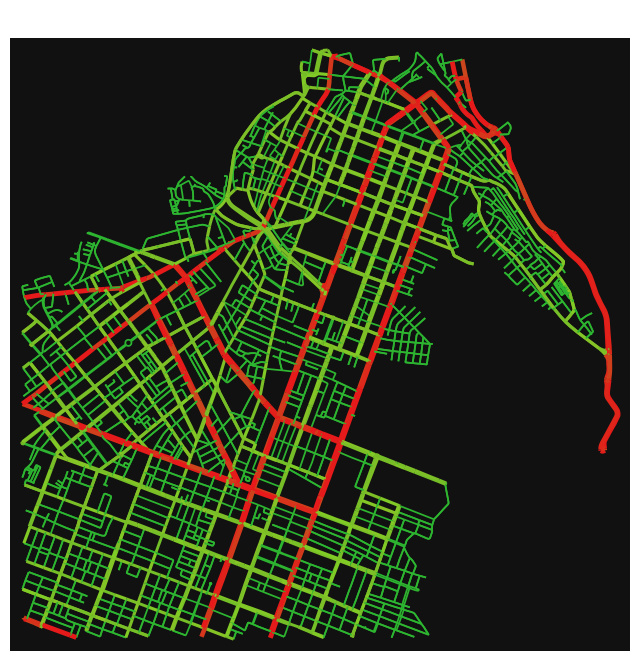

In [13]:
categorias_ruas = {
    'motorway': 'arterial', 
    'motorway_link': 'arterial',
    'trunk': 'arterial', 
    'trunk_link': 'arterial',
    'primary': 'arterial',
    'primary_link': 'arterial',
    'secondary': 'coletora', 
    'secondary_link': 'coletora',
    'tertiary': 'coletora', 
    'tertiary_link': 'coletora',
    'residential': 'residencial', 
    'living_street': 'residencial',
    'unclassified': 'residencial',
    'service': 'residencial',
}

fator_trafego = {
    'arterial': 2.0, 
    'coletora': 1.5, 
    'residencial': 1.1,
}

def obter_multiplicador_pico(hora):
    """
    Retorna o fator de congestionamento (0.0 = nenhum, 1.0 = padrão).
    Pico da manhã: 07h-09h (até +0.30 sobre o padrão)
    Pico da tarde: 17h-19h (até +0.45 sobre o padrão)
    Madrugada: 22h-06h (sem congestionamento)
    Outros horários: congestionamento padrão
    """
    if 7.0 <= hora <= 9.0:
        dist = abs(hora - 8.0)
        return 1.0 + 0.30 * (1.0 - dist)
    elif 17.0 <= hora <= 19.0:
        dist = abs(hora - 18.0)
        return 1.0 + 0.45 * (1.0 - dist)
    elif 22.0 <= hora or hora <= 6.0:
        return 0.0
    else:
        return 1.0

def aplicar_transito_sintetico(grafo, hora=18.0, in_place=False, semente=42):
    """
    Aplica trânsito sintético no grafo baseado no tipo de via, no horário de pico e
    com uma componente estocástica (aleatória) para realismo.
    
    Retorna uma cópia do grafo com a propriedade 'travel_time_traffic' adicionada às arestas.
    """
    if not in_place:
        grafo = grafo.copy()
        
    if semente is not None:
        np.random.seed(semente)
        
    fator_pico = obter_multiplicador_pico(hora)
    
    for u, v, k, data in grafo.edges(keys=True, data=True):
        # Determina a categoria da via
        highway = data.get('highway', 'residencial')
        if isinstance(highway, list):
            highway = highway[0]
            
        categoria = categorias_ruas.get(highway, 'residencial')
        
        # Obtém o fator base da categoria e aplica o multiplicador de pico
        fator_base = fator_trafego.get(categoria, 1.0)
        
        # Adiciona variação estocástica (+/- 10%) para simular trânsito real e imprevisível
        variacao_estocastica = np.random.uniform(0.9, 1.1)
        
        # Fórmula aditiva: congestionamento é um acréscimo sobre o tempo livre
        # fator_pico=0.0 (madrugada) → fator_final=1.0, sem congestionamento
        fator_final = 1.0 + (fator_base - 1.0) * fator_pico * variacao_estocastica
        
        # Obtém o tempo de percurso base (travel_time)
        travel_time = data.get('travel_time', 0.0)
        
        # Fallback caso travel_time não esteja calculado
        if travel_time == 0.0 and 'length' in data:
            speed_kph = data.get('speed_kph', 30)
            if isinstance(speed_kph, list):
                speed_kph = speed_kph[0]
            speed_ms = speed_kph / 3.6
            travel_time = data['length'] / speed_ms if speed_ms > 0 else 1.0
            
        data['travel_time_traffic'] = travel_time * fator_final
        
    return grafo

def visualizar_transito(grafo, titulo="Visualização do Trânsito Sintético"):
    """
    Visualiza espacialmente o nível de congestionamento das vias do grafo.
    Cores: Verde (Fluido) -> Amarelo -> Vermelho (Congestionado).
    """
    cores = []
    larguras = []
    
    for u, v, k, data in grafo.edges(keys=True, data=True):
        t_base = data.get('travel_time', 1.0)
        t_trafego = data.get('travel_time_traffic', t_base)
        if t_base <= 0:
            t_base = 1.0
            
        # Fator de congestionamento real
        razao = t_trafego / t_base
        
        # Normaliza a razão de congestionamento de 1.0 (verde) a 2.5+ (vermelho)
        val = min(1.0, max(0.0, (razao - 1.0) / 1.5))
        
        # Gradiente suave de verde para vermelho:
        r = 0.1 + 0.8 * val
        g = 0.7 + 0.1 * val if val < 0.5 else 0.8 - 0.7 * (val - 0.5) * 2
        b = 0.2 - 0.1 * val
        cores.append((r, g, b))
        
        # Largura da linha maior para vias mais congestionadas
        largura = 1.0 + 2.5 * val
        larguras.append(largura)
    
    fig, ax = ox.plot_graph(
        grafo,
        node_size=0,
        edge_color=cores,
        edge_linewidth=larguras,
        bgcolor='#111111',
        show=False,
        close=False
    )
    ax.set_title(titulo, color='white', fontsize=14, pad=10)
    plt.show()

# --- TESTANDO ---

# 1. Gerar grafo com trânsito de pico (18:00) - Copiando o grafo para evitar mutar G
G_pico = aplicar_transito_sintetico(G, hora=18.0, in_place=False)

# 2. Gerar grafo fora de pico (23:00)
G_fora_pico = aplicar_transito_sintetico(G, hora=23.0, in_place=False)

# Exemplo de comparação de aresta
u, v, k, d_orig = list(G.edges(keys=True, data=True))[0]
_, _, _, d_pico = list(G_pico.edges(keys=True, data=True))[0]
_, _, _, d_fora = list(G_fora_pico.edges(keys=True, data=True))[0]

print("="*60)
print("COMPARAÇÃO DE ARESTAS (Trânsito Sintético)")
print("="*60)
print(f"Via: {d_orig.get('name', 'Sem nome')} ({d_orig.get('highway')})")
print(f"  Tempo base (Sem Trânsito): {d_orig.get('travel_time', 0.0):.2f}s")
print(f"  Tempo no Pico (18:00):      {d_pico.get('travel_time_traffic', 0.0):.2f}s")
print(f"  Tempo Fora de Pico (23:00): {d_fora.get('travel_time_traffic', 0.0):.2f}s")

# 3. Teste de comparação de rotas (Caminho mais rápido com e sem trânsito)
print("\n" + "="*60)
print("COMPARAÇÃO DE ROTAS (Com vs Sem Trânsito)")
print("="*60)
try:
    # Usando o algoritmo de Bellman-Ford já implementado na Seção 5.1
    caminho_sem = bellman_ford(G, A, B, weight='travel_time')
    caminho_com = bellman_ford(G_pico, A, B, weight='travel_time_traffic')
    
    print(f"Rota mais rápida SEM trânsito (tempo base):")
    print(f"  Tempo total: {caminho_sem['distancia']:.2f}s")
    print(f"  Número de nós no caminho: {len(caminho_sem['caminho'])}")
    
    print(f"\nRota mais rápida COM trânsito (Pico 18h):")
    print(f"  Tempo total: {caminho_com['distancia']:.2f}s")
    print(f"  Número de nós no caminho: {len(caminho_com['caminho'])}")
    
    diferentes = caminho_sem['caminho'] != caminho_com['caminho']
    print(f"\nOs caminhos escolhidos são diferentes? {'SIM' if diferentes else 'NÃO'}")
except NameError as e:
    print(f"Nota: Certifique-se de executar as células das Seções anteriores primeiro! Erro: {e}")

# 4. Visualizar o trânsito no horário de pico
visualizar_transito(G_pico, titulo="Trânsito Sintético no Horário de Pico (18h)")

## 7. Candidatos de embarque

Para encontrar todos os pontos de embarque `P` viáveis:

1. Executamos Dijkstra no grafo de caminhada (`G_walk`) a partir de `A`
2. Calculamos a distância real ao longo das ruas (não euclidiana)
3. Filtramos candidatos com distância ≤ `X` metros

Isso garante que cada candidato `P` é alcançável a pé dentro da restrição do usuário.

In [14]:
def dijkstra_caminhada(G_walk, origem, weight='length'):
    """
    Executa o algoritmo de Dijkstra manual de fonte única a partir de uma origem
    no grafo G_walk usando o peso especificado (comprimento/distância real).
    """
    dist = {n: float('inf') for n in G_walk.nodes()}
    dist[origem] = 0.0
    
    pq = [(0.0, origem)]
    fechado = set()
    
    while pq:
        dist_atual, atual = heapq.heappop(pq)
        if atual in fechado:
            continue
        fechado.add(atual)
        
        for vizinho, peso in vizinhos_ponderados(G_walk, atual, weight):
            novo_custo = dist_atual + peso
            if novo_custo < dist[vizinho]:
                dist[vizinho] = novo_custo
                heapq.heappush(pq, (novo_custo, vizinho))
                
    return dist

def encontrar_candidatos_embarque(G_walk, G, origem_walk, max_dist, weight='length'):
    """
    Implementa a enumeração de candidatos de embarque P no notebook.
    
    - Executa Dijkstra no G_walk a partir de origem_walk
    - Retorna dict com os candidatos que estão dentro do limite max_dist (metros)
      e que existem no grafo de carro G (onde o carro pode de fato acessar).
    """
    # 1. Dijkstra executado no G_walk para obter distâncias de origem_walk a todos os nós
    dist_walk = dijkstra_caminhada(G_walk, origem_walk, weight=weight)
    
    # 2. Filtrar candidatos com distância <= max_dist e que pertencem ao grafo G
    candidatos_factiveis = {
        no: dist for no, dist in dist_walk.items()
        if dist <= max_dist and no in G.nodes()
    }
    
    return candidatos_factiveis

In [15]:
# Teste: verificar se os candidatos de embarque estão dentro do limite X
print("="*60)
print("ENUMERAÇÃO DE CANDIDATOS DE EMBARQUE")
print("="*60)

candidatos_dist = encontrar_candidatos_embarque(G_walk, G, A_walk, X)

print(f"Distância máxima de caminhada permitida (X): {X} metros")
print(f"Quantidade de candidatos factíveis encontrados: {len(candidatos_dist)}")

# Amostra de candidatos
print("\nAmostra dos 5 primeiros candidatos encontrados:")
for i, (no_cand, dist_cand) in enumerate(list(candidatos_dist.items())[:5]):
    print(f"  Candidato {i+1}: Nó {no_cand} | Distância real de A_walk: {dist_cand:.2f} metros")

# Verificações de corretude
assert len(candidatos_dist) > 0, "Erro: Nenhum candidato de embarque encontrado!"
assert all(dist <= X for dist in candidatos_dist.values()), "Erro: Existe candidato com distância maior que X!"
assert all(no in G.nodes() for no in candidatos_dist.keys()), "Erro: Existe candidato que não pertence ao grafo G!"

ENUMERAÇÃO DE CANDIDATOS DE EMBARQUE
Distância máxima de caminhada permitida (X): 600.0 metros
Quantidade de candidatos factíveis encontrados: 137

Amostra dos 5 primeiros candidatos encontrados:
  Candidato 1: Nó 301648785 | Distância real de A_walk: 572.58 metros
  Candidato 2: Nó 301648787 | Distância real de A_walk: 559.50 metros
  Candidato 3: Nó 302602038 | Distância real de A_walk: 431.87 metros
  Candidato 4: Nó 302602041 | Distância real de A_walk: 232.85 metros
  Candidato 5: Nó 302603011 | Distância real de A_walk: 512.10 metros


## 8. Função de avaliação

A função `avaliar_rota(G, G_walk, A, B, P, dist_walk, traffic_map)` encapsula:

- Execução dos 4 algoritmos no grafo de carro (`G`)
- Cálculo de distância e tempo para cada algoritmo
- Inclusão do tempo de caminhada `A → P`
- Retorno de dict com todas as métricas para um candidato `P`

Essa função será chamada para cada candidato, gerando o DataFrame de comparação.

In [16]:
def avaliar_rota(G, G_walk, A, B, P, dist_walk, traffic_map):
    """
    Avalia a rota A→P (a pé) + P→B (de carro) para um candidato P.

    Parâmetros
    ----------
    G           : nx.MultiDiGraph — grafo dirigido de carro (com 'travel_time' e 'length')
    G_walk      : nx.MultiDiGraph — grafo de caminhada (com 'length')
    A           : int — nó de origem no grafo walk
    B           : int — nó de destino no grafo drive
    P           : int — nó candidato de embarque (presente no grafo drive)
    dist_walk   : float — distância de caminhada A→P em metros (pré-calculada)
    traffic_map : nx.MultiDiGraph — grafo de carro com 'travel_time_traffic' aplicado

    Retorna
    -------
    dict com:
        'P'         : nó candidato
        'dist_walk' : distância de caminhada A→P (metros)
        'tempo_walk' : tempo de caminhada A→P (segundos)
        'algoritmos' : dict com métricas por algoritmo
    """
    # Velocidade de caminhada (m/s) — mesma constante usada na seção 4
    v_pe = 1.4
    tempo_walk = dist_walk / v_pe

    # Algoritmos disponíveis
    algoritmos = {
        'dijkstra_simples': dijkstra_simples,
        'dijkstra_heap':    dijkstra_heap,
        'a_estrela':        a_estrela,
        'bellman_ford':     bellman_ford,
    }

    resultados_algoritmos = {}
    # Pré-computa distância P→B (independe do algoritmo de rota)
    res_dist_base = dijkstra_heap(G, P, B, weight='length')


    for nome, func in algoritmos.items():

        # --- Tempo sem trânsito (segundos) P→B ---
        res_tempo = func(G, P, B, weight='travel_time')

        # --- Tempo com trânsito (segundos) P→B ---
        res_transito = func(traffic_map, P, B, weight='travel_time_traffic')

        resultados_algoritmos[nome] = {
            # Métricas do trecho P→B
            'dist_carro':           res_dist_base['distancia'],
            'tempo_carro':          res_tempo['distancia'],
            'tempo_carro_transito': res_transito['distancia'],
            # Métricas totais A→P→B
            'dist_total':           dist_walk + res_dist_base['distancia'],
            'tempo_total':          tempo_walk + res_tempo['distancia'],
            'tempo_total_transito': tempo_walk + res_transito['distancia'],
            # Metadados de execução
            'expandidos':           res_tempo['expandidos'],
            'tempo_execucao':       res_tempo['tempo'] + res_transito['tempo'],
            'caminho_dist':         res_dist_base['caminho'],
            'caminho_tempo':        res_tempo['caminho'],
            'caminho_transito':     res_transito['caminho'],
        }

    return {
        'P':          P,
        'dist_walk':  dist_walk,
        'tempo_walk': tempo_walk,
        'algoritmos': resultados_algoritmos,
    }

In [17]:
# ============================================================
# TESTE da função avaliar_rota
# ============================================================
# Caso trivial: P = A (sem caminhada)
# O nó A do grafo drive é usado como candidato de embarque.
# dist_walk = 0 (o usuário já está no ponto de embarque)

# Garante que o grafo com trânsito existe
if 'G_pico' not in globals():
    G_pico = aplicar_transito_sintetico(G, hora=18.0, in_place=False)

print("="*60)
print("TESTE — avaliar_rota (P = A, dist_walk = 0)")
print("="*60)

resultado_teste = avaliar_rota(
    G=G, G_walk=G_walk, A=A, B=B,
    P=A,           # candidato = própria origem
    dist_walk=0.0, # sem caminhada
    traffic_map=G_pico
)

# --- Exibição dos resultados ---
print(f"\nCandidato P = {resultado_teste['P']}")
print(f"Dist. caminhada: {resultado_teste['dist_walk']:.1f} m")
print(f"Tempo caminhada: {resultado_teste['tempo_walk']:.1f} s")

for nome_algo, metricas in resultado_teste['algoritmos'].items():
    print(f"\n  [{nome_algo}]")
    print(f"    Dist. carro P→B:       {metricas['dist_carro']:.1f} m")
    print(f"    Tempo carro (s/ trâns): {metricas['tempo_carro']:.1f} s")
    print(f"    Tempo carro (c/ trâns): {metricas['tempo_carro_transito']:.1f} s")
    print(f"    Dist. total A→P→B:     {metricas['dist_total']:.1f} m")
    print(f"    Tempo total (s/ trâns): {metricas['tempo_total']:.1f} s")
    print(f"    Tempo total (c/ trâns): {metricas['tempo_total_transito']:.1f} s")
    print(f"    Nós expandidos:         {metricas['expandidos']}")
    print(f"    Tempo execução:         {metricas['tempo_execucao']*1000:.2f} ms")

# --- Validações automáticas ---
print("\n" + "="*60)
print("VALIDAÇÕES")
print("="*60)

algos = list(resultado_teste['algoritmos'].keys())
dist_ref = resultado_teste['algoritmos'][algos[0]]['dist_carro']
tempo_ref = resultado_teste['algoritmos'][algos[0]]['tempo_carro']

ok_dist = all(
    abs(resultado_teste['algoritmos'][a]['dist_carro'] - dist_ref) < 1e-6
    for a in algos
)
ok_tempo = all(
    abs(resultado_teste['algoritmos'][a]['tempo_carro'] - tempo_ref) < 1e-6
    for a in algos
)
ok_transito = all(
    resultado_teste['algoritmos'][a]['tempo_total_transito'] >=
    resultado_teste['algoritmos'][a]['tempo_total'] - 1e-6
    for a in algos
)
ok_keys = all(
    set(resultado_teste['algoritmos'][a].keys()) == {
        'dist_carro', 'tempo_carro', 'tempo_carro_transito',
        'dist_total', 'tempo_total', 'tempo_total_transito',
        'expandidos', 'tempo_execucao',
        'caminho_dist', 'caminho_tempo', 'caminho_transito'
    }
    for a in algos
)

print(f"  Corretude distância (todos iguais):  {'PASS' if ok_dist else 'FAIL'}")
print(f"  Corretude tempo (todos iguais):      {'PASS' if ok_tempo else 'FAIL'}")
print(f"  Trânsito >= sem trânsito:            {'PASS' if ok_transito else 'FAIL'}")
print(f"  Estrutura do dict completa:          {'PASS' if ok_keys else 'FAIL'}")
print(f"  4 algoritmos presentes:              {'PASS' if len(algos) == 4 else 'FAIL'}")

if all([ok_dist, ok_tempo, ok_transito, ok_keys, len(algos) == 4]):
    print("\nTodos os testes passaram.")
else:
    print("\n Algum teste apresentou falha.")

TESTE — avaliar_rota (P = A, dist_walk = 0)

Candidato P = 8626298111
Dist. caminhada: 0.0 m
Tempo caminhada: 0.0 s

  [dijkstra_simples]
    Dist. carro P→B:       2801.8 m
    Tempo carro (s/ trâns): 237.8 s
    Tempo carro (c/ trâns): 449.5 s
    Dist. total A→P→B:     2801.8 m
    Tempo total (s/ trâns): 237.8 s
    Tempo total (c/ trâns): 449.5 s
    Nós expandidos:         1733
    Tempo execução:         423.00 ms

  [dijkstra_heap]
    Dist. carro P→B:       2801.8 m
    Tempo carro (s/ trâns): 237.8 s
    Tempo carro (c/ trâns): 449.5 s
    Dist. total A→P→B:     2801.8 m
    Tempo total (s/ trâns): 237.8 s
    Tempo total (c/ trâns): 449.5 s
    Nós expandidos:         1733
    Tempo execução:         15.01 ms

  [a_estrela]
    Dist. carro P→B:       2801.8 m
    Tempo carro (s/ trâns): 237.8 s
    Tempo carro (c/ trâns): 449.5 s
    Dist. total A→P→B:     2801.8 m
    Tempo total (s/ trâns): 237.8 s
    Tempo total (c/ trâns): 449.5 s
    Nós expandidos:         621
    Tem

## 9. Comparação e DataFrame

Com as métricas coletadas, geramos um DataFrame pandas com:

- Uma linha por candidato `P`
- Colunas: distância walk, distância carro, tempo total, tempo com trânsito, algoritmo usado

As **5 comparações obrigatórias**:
1. Menor rota em distância
2. Rota mais rápida sem trânsito
3. Rota mais rápida com trânsito sintético
4. Caso sem caminhada (A → B direto)
5. Ganho obtido ao caminhar até outro ponto de embarque

In [18]:


# Garantir que os grafos com trânsito para diferentes horários estejam gerados
if 'G_pico_manha' not in globals():
    G_pico_manha = aplicar_transito_sintetico(G, hora=8.0, in_place=False)
if 'G_pico_tarde' not in globals():
    G_pico_tarde = aplicar_transito_sintetico(G, hora=18.0, in_place=False)
if 'G_fora_pico' not in globals():
    G_fora_pico = aplicar_transito_sintetico(G, hora=23.0, in_place=False)

# 1. Encontrar candidatos P no grafo de caminhada (distância real <= X metros)
print("="*60)
print(f"GERANDO CANDIDATOS (Caminhada <= {X}m)")
print("="*60)

# nx.single_source_dijkstra_path_length retorna um dict: {nó: distância}
dist_walk_all = nx.single_source_dijkstra_path_length(G_walk, A_walk, cutoff=X, weight='length')

# Filtramos apenas os nós que também estão na malha de carro (G)
candidatos_P = {n: d for n, d in dist_walk_all.items() if n in G.nodes()}

# Garantimos que A esteja presente para a comparação "sem caminhada"
if A not in candidatos_P:
    candidatos_P[A] = 0.0

print(f"Total de nós alcançáveis a pé (G_walk): {len(dist_walk_all)}")
print(f"Candidatos P válidos (na malha de carro): {len(candidatos_P)}")

# 2. Avaliar rotas para cada candidato e criar DataFrame com trânsito em horas distintas
print("\n" + "="*60)
print("AVALIANDO CANDIDATOS E GERANDO DATAFRAME")
print("="*60)

v_pe = 1.4
algoritmos = {
    'dijkstra_simples': dijkstra_simples,
    'dijkstra_heap':    dijkstra_heap,
    'a_estrela':        a_estrela,
    'bellman_ford':     bellman_ford,
}

linhas = []
for p, d_walk in candidatos_P.items():
    tempo_walk = d_walk / v_pe
    
    # Pré-computa distância P→B (independe do algoritmo de rota)
    res_dist_base = dijkstra_heap(G, p, B, weight='length')
    
    for algo, func in algoritmos.items():
        # --- Execuções básicas comuns ---
        res_tempo = func(G, p, B, weight='travel_time')
        
        # --- Execuções em horários de trânsito distintos ---
        res_transito_8h = func(G_pico_manha, p, B, weight='travel_time_traffic')
        res_transito_18h = func(G_pico_tarde, p, B, weight='travel_time_traffic')
        res_transito_23h = func(G_fora_pico, p, B, weight='travel_time_traffic')
        
        linhas.append({
            'candidato': p,
            'algoritmo': algo,
            'dist_walk': d_walk,
            'dist_carro': res_dist_base['distancia'],
            'dist_total': d_walk + res_dist_base['distancia'],
            'tempo_carro': res_tempo['distancia'],
            'tempo_total': tempo_walk + res_tempo['distancia'],
            
            # Trânsito 8h (Pico Manhã)
            'tempo_carro_transito_8h': res_transito_8h['distancia'],
            'tempo_total_transito_8h': tempo_walk + res_transito_8h['distancia'],
            
            # Trânsito 18h (Pico Tarde)
            'tempo_carro_transito_18h': res_transito_18h['distancia'],
            'tempo_total_transito_18h': tempo_walk + res_transito_18h['distancia'],
            
            # Trânsito 23h (Fora de Pico/Noite)
            'tempo_carro_transito_23h': res_transito_23h['distancia'],
            'tempo_total_transito_23h': tempo_walk + res_transito_23h['distancia'],
            
            'expandidos': res_tempo['expandidos'],
            'caminhos_distintos_8h': res_tempo['caminho'] != res_transito_8h['caminho'],
            'caminhos_distintos_18h': res_tempo['caminho'] != res_transito_18h['caminho'],
            'caminhos_distintos_23h': res_tempo['caminho'] != res_transito_23h['caminho'],
            
            # Caminhos guardados internamente
            'caminho_dist': res_dist_base['caminho'],
            'caminho_tempo': res_tempo['caminho'],
            'caminho_transito_8h': res_transito_8h['caminho'],
            'caminho_transito_18h': res_transito_18h['caminho'],
            'caminho_transito_23h': res_transito_23h['caminho']
        })

df_resultados = pd.DataFrame(linhas)
print(f"DataFrame gerado com {len(df_resultados)} linhas ({(len(candidatos_P))} candidatos x 4 algoritmos)")

# Exibição limpa do DataFrame (sem mostrar os caminhos extensos de nós)
colunas_exibicao = [col for col in df_resultados.columns if not col.startswith('caminho_')]
display(df_resultados[colunas_exibicao].head())

# 3. As 5 comparações obrigatórias
print("\n" + "="*60)
print("AS 5 COMPARAÇÕES OBRIGATÓRIAS")
print("="*60)

# O A* geográfico foi o mais rápido, usaremos ele como base para as comparações.
df_astar = df_resultados[df_resultados['algoritmo'] == 'a_estrela'].copy()

# 1. Menor rota em distância
melhor_dist = df_astar.loc[df_astar['dist_total'].idxmin()]
print(f"1. Menor rota em distância (candidato {melhor_dist['candidato']}): {melhor_dist['dist_total']:.1f} m")

# 2. Rota mais rápida sem trânsito
melhor_tempo = df_astar.loc[df_astar['tempo_total'].idxmin()]
print(f"2. Rota mais rápida sem trânsito (candidato {melhor_tempo['candidato']}): {melhor_tempo['tempo_total']:.1f} s")

# 3. Rota mais rápida com trânsito em horas distintas
melhor_tempo_8h = df_astar.loc[df_astar['tempo_total_transito_8h'].idxmin()]
melhor_tempo_18h = df_astar.loc[df_astar['tempo_total_transito_18h'].idxmin()]
melhor_tempo_23h = df_astar.loc[df_astar['tempo_total_transito_23h'].idxmin()]
print(f"3. Rota mais rápida com trânsito em horas distintas:")
print(f"   - Manhã (08:00) (candidato {melhor_tempo_8h['candidato']}): {melhor_tempo_8h['tempo_total_transito_8h']:.1f} s")
print(f"   - Tarde (18:00) (candidato {melhor_tempo_18h['candidato']}): {melhor_tempo_18h['tempo_total_transito_18h']:.1f} s")
print(f"   - Noite (23:00) (candidato {melhor_tempo_23h['candidato']}): {melhor_tempo_23h['tempo_total_transito_23h']:.1f} s")

# 4. Caso sem caminhada (A -> B direto)
caso_sem_caminhada = df_astar[df_astar['candidato'] == A].iloc[0]
print(f"4. Caso sem caminhada (A -> B direto):")
print(f"   Distância total: {caso_sem_caminhada['dist_total']:.1f} m")
print(f"   Tempo sem trânsito: {caso_sem_caminhada['tempo_total']:.1f} s")
print(f"   Tempo com trânsito (08:00): {caso_sem_caminhada['tempo_total_transito_8h']:.1f} s")
print(f"   Tempo com trânsito (18:00): {caso_sem_caminhada['tempo_total_transito_18h']:.1f} s")
print(f"   Tempo com trânsito (23:00): {caso_sem_caminhada['tempo_total_transito_23h']:.1f} s")

# 5. Ganho obtido ao caminhar
ganho_dist = caso_sem_caminhada['dist_total'] - melhor_dist['dist_total']
ganho_tempo = caso_sem_caminhada['tempo_total'] - melhor_tempo['tempo_total']
ganho_tempo_8h = caso_sem_caminhada['tempo_total_transito_8h'] - melhor_tempo_8h['tempo_total_transito_8h']
ganho_tempo_18h = caso_sem_caminhada['tempo_total_transito_18h'] - melhor_tempo_18h['tempo_total_transito_18h']
ganho_tempo_23h = caso_sem_caminhada['tempo_total_transito_23h'] - melhor_tempo_23h['tempo_total_transito_23h']

print(f"\n5. Ganho obtido ao caminhar até o melhor ponto:")
print(f"   Redução de distância: {ganho_dist:.1f} m")
print(f"   Redução de tempo sem trânsito: {ganho_tempo:.1f} s")
print(f"   Redução de tempo com trânsito (08:00): {ganho_tempo_8h:.1f} s")
print(f"   Redução de tempo com trânsito (18:00): {ganho_tempo_18h:.1f} s")
print(f"   Redução de tempo com trânsito (23:00): {ganho_tempo_23h:.1f} s")

GERANDO CANDIDATOS (Caminhada <= 600.0m)
Total de nós alcançáveis a pé (G_walk): 231
Candidatos P válidos (na malha de carro): 137

AVALIANDO CANDIDATOS E GERANDO DATAFRAME
DataFrame gerado com 548 linhas (137 candidatos x 4 algoritmos)


,candidato,algoritmo,dist_walk,dist_carro,dist_total,tempo_carro,tempo_total,tempo_carro_transito_8h,tempo_total_transito_8h,tempo_carro_transito_18h,tempo_total_transito_18h,tempo_carro_transito_23h,tempo_total_transito_23h,expandidos,caminhos_distintos_8h,caminhos_distintos_18h,caminhos_distintos_23h
0,529717601,dijkstra_simples,115.132984,2865.987474,2981.120458,238.692789,320.930635,439.593684,521.83153,460.014558,542.252404,238.692789,320.930635,1739,True,True,False
1,529717601,dijkstra_heap,115.132984,2865.987474,2981.120458,238.692789,320.930635,439.593684,521.83153,460.014558,542.252404,238.692789,320.930635,1739,True,True,False
2,529717601,a_estrela,115.132984,2865.987474,2981.120458,238.692789,320.930635,439.593684,521.83153,460.014558,542.252404,238.692789,320.930635,645,True,True,False
3,529717601,bellman_ford,115.132984,2865.987474,2981.120458,238.692789,320.930635,439.593684,521.83153,460.014558,542.252404,238.692789,320.930635,290766,True,True,False
4,529717600,dijkstra_simples,125.108978,2875.963468,3001.072446,239.604441,328.967997,441.074675,530.43823,461.561241,550.924797,239.604441,328.967997,1746,True,True,False



AS 5 COMPARAÇÕES OBRIGATÓRIAS
1. Menor rota em distância (candidato 526593055): 2912.1 m
2. Rota mais rápida sem trânsito (candidato 529717601): 320.9 s
3. Rota mais rápida com trânsito em horas distintas:
   - Manhã (08:00) (candidato 8626298111): 521.2 s
   - Tarde (18:00) (candidato 8626298111): 540.7 s
   - Noite (23:00) (candidato 529717601): 320.9 s
4. Caso sem caminhada (A -> B direto):
   Distância total: 2929.4 m
   Tempo sem trânsito: 329.0 s
   Tempo com trânsito (08:00): 521.2 s
   Tempo com trânsito (18:00): 540.7 s
   Tempo com trânsito (23:00): 329.0 s

5. Ganho obtido ao caminhar até o melhor ponto:
   Redução de distância: 17.2 m
   Redução de tempo sem trânsito: 8.0 s
   Redução de tempo com trânsito (08:00): 0.0 s
   Redução de tempo com trânsito (18:00): 0.0 s
   Redução de tempo com trânsito (23:00): 8.0 s


## 10. Visualizações

Quatro tipos de visualização:

1. **Mapa estático**: rede viária + candidatos P + rotas escolhidas
2. **Gráfico de barras**: comparar tempo/distância entre os 4 algoritmos
3. **Gráfico de dispersão**: relação entre caminhada e tempo total
4. **Tabela estilizada**: DataFrame com gradientes de cor

In [19]:

def plot_interactive_map(G, G_walk, A, B, candidatos_P, melhor_P, path_walk, path_drive):
    fig = go.Figure()

    # 1. Plotar os candidatos P
    lats_p = [G.nodes[p]['y'] for p in candidatos_P]
    lons_p = [G.nodes[p]['x'] for p in candidatos_P]
    
    fig.add_trace(go.Scattermapbox(
        lat=lats_p,
        lon=lons_p,
        mode='markers',
        marker=go.scattermapbox.Marker(size=6, color='blue', opacity=0.6),
        name='Candidatos P'
    ))

    # 2. Plotar Rota de Caminhada (A -> P)
    if path_walk:
        lats_w = [G_walk.nodes[n]['y'] for n in path_walk]
        lons_w = [G_walk.nodes[n]['x'] for n in path_walk]
        fig.add_trace(go.Scattermapbox(
            lat=lats_w,
            lon=lons_w,
            mode='lines',
            line=dict(width=4, color='orange'),
            name='Caminhada (A -> P_best)'
        ))

    # 3. Plotar Rota de Carro (P -> B)
    if path_drive:
        lats_d = [G.nodes[n]['y'] for n in path_drive]
        lons_d = [G.nodes[n]['x'] for n in path_drive]
        fig.add_trace(go.Scattermapbox(
            lat=lats_d,
            lon=lons_d,
            mode='lines',
            line=dict(width=4, color='green'),
            name='Carro (P_best -> B)'
        ))

    # 4. Plotar A, B, e P_best
    fig.add_trace(go.Scattermapbox(
        lat=[G_walk.nodes[A]['y'], G.nodes[B]['y'], G.nodes[melhor_P]['y']],
        lon=[G_walk.nodes[A]['x'], G.nodes[B]['x'], G.nodes[melhor_P]['x']],
        mode='markers+text',
        marker=go.scattermapbox.Marker(size=12, color=['red', 'green', 'purple']),
        text=['Origem A', 'Destino B', 'Melhor P'],
        textposition='bottom right',
        name='Pontos Principais'
    ))

    center_lat = (G_walk.nodes[A]['y'] + G.nodes[B]['y']) / 2
    center_lon = (G_walk.nodes[A]['x'] + G.nodes[B]['x']) / 2

    fig.update_layout(
        title="Rotas Interativas (A -> P -> B)",
        mapbox_style="carto-positron",
        mapbox=dict(
            center=go.layout.mapbox.Center(lat=center_lat, lon=center_lon),
            zoom=12
        ),
        margin={"r":0,"t":40,"l":0,"b":0}
    )
    
    return fig

print("Gerando Mapa Interativo...")
melhor_P = melhor_tempo_18h['candidato']
caminho_str = melhor_tempo_18h['caminho_transito_18h']
# O caminho está como string na coluna se não for lista. Caso seja lista, usamos direto.
path_drive = ast.literal_eval(caminho_str) if isinstance(caminho_str, str) else caminho_str

# Para obter path_walk, usamos nx.shortest_path no G_walk
path_walk = nx.shortest_path(G_walk, A_walk, melhor_P, weight='length') if melhor_P != A else []

fig = plot_interactive_map(G, G_walk, A_walk, B, list(candidatos_P.keys()), melhor_P, path_walk, path_drive)
fig.write_html('mapa_interativo.html')
print("Mapa exportado como 'mapa_interativo.html'")
fig.show()


Gerando Mapa Interativo...
Mapa exportado como 'mapa_interativo.html'


/tmp/ipykernel_76401/3889569976.py:8: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
/tmp/ipykernel_76401/3889569976.py:32: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
/tmp/ipykernel_76401/3889569976.py:41: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


## 11. Animações

Duas abordagens de animação:

### Matplotlib GIF
- 4 GIFs individuais (um por algoritmo) mostrando expansão de nós
- 1 GIF comparativo (lado a lado ou sequencial)

### Plotly interativo
- Mapa interativo com candidatos P + rotas
- Zoom/pan no navegador
- Exporta HTML standalone

In [20]:

print("Gerando históricos de expansão...")
P_start = melhor_P
B_end = B

res_simples, hist_simples = dijkstra_simples(G, P_start, B_end, track_history=True)
res_heap, hist_heap = dijkstra_heap(G, P_start, B_end, track_history=True)
res_astar, hist_astar = a_estrela(G, P_start, B_end, track_history=True)
res_bf, hist_bf = bellman_ford(G, P_start, B_end, track_history=True)
path_simples = res_simples['caminho']
path_heap = res_heap['caminho']
path_astar = res_astar['caminho']
path_bf = res_bf['caminho']

hist_simples = hist_simples[:800]
hist_heap = hist_heap[:800]
hist_astar = hist_astar[:800]
hist_bf = hist_bf[:800]

print("Históricos prontos. Criando GIFs...")

def save_anim(hist, path, title, filename):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    nodes_x = [G.nodes[n]['x'] for n in hist]
    nodes_y = [G.nodes[n]['y'] for n in hist]
    
    # Coordenadas do caminho a pé (se existir)
    pw_x = [G_walk.nodes[n]['x'] for n in path_walk] if 'path_walk' in globals() and path_walk else []
    pw_y = [G_walk.nodes[n]['y'] for n in path_walk] if 'path_walk' in globals() and path_walk else []
    
    all_x = nodes_x + pw_x
    all_y = nodes_y + pw_y
    
    if not all_x:
        return
        
    min_x, max_x = min(all_x)-0.01, max(all_x)+0.01
    min_y, max_y = min(all_y)-0.01, max(all_y)+0.01
    
    sub_nodes = [n for n, d in G.nodes(data=True) if min_x <= d['x'] <= max_x and min_y <= d['y'] <= max_y]
    G_sub = G.subgraph(sub_nodes)
    
    ox.plot_graph(G_sub, ax=ax, show=False, close=False, node_size=0, edge_color='#999999', edge_linewidth=0.5)
    
    # Desenhar o caminho a pé fixo
    if pw_x:
        ax.plot(pw_x, pw_y, c='orange', linestyle='--', linewidth=2, zorder=2, label='Caminhada (A -> P)')
        ax.legend(loc="upper left")
        
    scat = ax.scatter([], [], c='blue', s=20, alpha=0.6, zorder=3)
    path_line, = ax.plot([], [], c='lime', linewidth=3, zorder=4)
    ax.set_title(title)
    
    path_x = [G.nodes[n]['x'] for n in path]
    path_y = [G.nodes[n]['y'] for n in path]
    
    frames = max(1, len(hist)//10) + 20 # +20 frames no final (2 segundos)
    
    def update(num):
        idx = min(num * 10, len(hist))
        nodes = hist[:idx]
        if not nodes: 
            return scat, path_line
        x = [G.nodes[n]['x'] for n in nodes]
        y = [G.nodes[n]['y'] for n in nodes]
        scat.set_offsets(np.c_[x, y])
        
        if idx >= len(hist):
            path_line.set_data(path_x, path_y)
        else:
            path_line.set_data([], [])
            
        return scat, path_line

    ani = FuncAnimation(fig, update, frames=frames, blit=True)
    ani.save(filename, writer=PillowWriter(fps=10))
    plt.close(fig)

save_anim(hist_simples, path_simples, 'Dijkstra Simples', 'anim_dijkstra_simples.gif')
save_anim(hist_heap, path_heap, 'Dijkstra Heap', 'anim_dijkstra_heap.gif')
save_anim(hist_astar, path_astar, 'A* Geográfico', 'anim_astar.gif')
save_anim(hist_bf, path_bf, 'Bellman-Ford', 'anim_bellman_ford.gif')

# GIF comparativo
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
titles = ['Dijkstra Simples', 'Dijkstra Heap', 'A* Geográfico', 'Bellman-Ford']
hists = [hist_simples, hist_heap, hist_astar, hist_bf]
paths = [path_simples, path_heap, path_astar, path_bf]

pw_x = [G_walk.nodes[n]['x'] for n in path_walk] if 'path_walk' in globals() and path_walk else []
pw_y = [G_walk.nodes[n]['y'] for n in path_walk] if 'path_walk' in globals() and path_walk else []

scats = []
path_lines = []
for i, ax in enumerate(axs):
    nodes_x = [G.nodes[n]['x'] for n in hists[i]]
    nodes_y = [G.nodes[n]['y'] for n in hists[i]]
    
    all_x = nodes_x + pw_x
    all_y = nodes_y + pw_y
    
    if all_x:
        min_x, max_x = min(all_x)-0.01, max(all_x)+0.01
        min_y, max_y = min(all_y)-0.01, max(all_y)+0.01
        sub_nodes = [n for n, d in G.nodes(data=True) if min_x <= d['x'] <= max_x and min_y <= d['y'] <= max_y]
        G_sub = G.subgraph(sub_nodes)
        
        ox.plot_graph(G_sub, ax=ax, show=False, close=False, node_size=0, edge_color='#999999', edge_linewidth=0.5)
        
        if pw_x:
            ax.plot(pw_x, pw_y, c='orange', linestyle='--', linewidth=2, zorder=2)
    
    scat = ax.scatter([], [], c='red', s=20, alpha=0.6, zorder=3)
    path_line, = ax.plot([], [], c='lime', linewidth=3, zorder=4)
    scats.append(scat)
    path_lines.append(path_line)
    ax.set_title(titles[i])

def update_comp(num):
    artists = []
    for i, ax in enumerate(axs):
        idx = min(num * 10, len(hists[i]))
        nodes = hists[i][:idx]
        if nodes:
            x = [G.nodes[n]['x'] for n in nodes]
            y = [G.nodes[n]['y'] for n in nodes]
            scats[i].set_offsets(np.c_[x, y])
            
        if idx >= len(hists[i]):
            p_x = [G.nodes[n]['x'] for n in paths[i]]
            p_y = [G.nodes[n]['y'] for n in paths[i]]
            path_lines[i].set_data(p_x, p_y)
        else:
            path_lines[i].set_data([], [])
            
        artists.append(scats[i])
        artists.append(path_lines[i])
    return artists

max_len = max([len(h) for h in hists])
frames_comp = max(1, max_len//10) + 20 # +20 frames no final (2 segundos)
ani_comp = FuncAnimation(fig, update_comp, frames=frames_comp, blit=True)
ani_comp.save('anim_comparativo.gif', writer=PillowWriter(fps=10))
plt.close(fig)
print("GIFs gerados e salvos!")


Gerando históricos de expansão...
Históricos prontos. Criando GIFs...
GIFs gerados e salvos!


## 12. Análise dos resultados

### 1. Como o problema foi modelado como grafo?

O problema de otimização de rotas urbanas foi modelado como um grafo direcionado ponderado ``G`` com **3.104 nós** e **6.762 arestas**, extraído do OpenStreetMap via OSMnx a partir de um ponto central ``CENTRO = (lat, lon)`` configurável e um raio de **2.500 m**. O usuário parte de uma origem ``A``, caminha até um ponto de embarque ``P`` (a no máximo **600 m**) e segue de carro até o destino ``B``. Formalmente, busca-se o ``P`` que minimiza ``caminhada(A → P) + carro(P → B)``. Um segundo grafo ``G_walk`` com **4.932 nós** e **14.462 arestas** representa as vias pedestrians. Os pontos ``A`` e ``B`` são definidos por coordenadas e mapeados aos nós mais próximos via ``ox.distance.nearest_nodes``, garantindo que pertencem à malha viária.

### 2. O que representam nós e arestas?

Cada nó representa uma **interseção viária** identificada por um ID único do OpenStreetMap, com atributos ``x`` (longitude) e ``y`` (latitude). Cada aresta dirigida representa um **trecho de via** entre duas interseções, com atributos: ``length`` (metros), ``travel_time`` (segundos), ``speed_kph``, ``name`` (logradouro) e ``highway`` (classificação: *primary*, *secondary*, *residential*, etc.). No grafo de caminhada, as arestas incluem calçadas e vias locais pedestrians.

### 3. Quais pesos foram usados?

Três pesos foram empregados: (1) ``length`` (distância do trecho em metros), (2) ``travel_time`` (tempo sem trânsito, dado por ``length / (speed_kph / 3.6)`` em segundos) e (3) ``travel_time_traffic`` (tempo com trânsito sintético, gerado por ``aplicar_transito_sintetico()``, que multiplica o tempo base por fatores que variam conforme o horário de 8h, 18h, 23h e o tipo de via). A heurística do A* usa a distância euclidiana entre coordenadas dividida pela velocidade máxima do grafo (70 km/h).

### 4. Como trânsito sintético alterou rotas?

O trânsito no horário de pico (18h) elevou o tempo da rota de **237,83 s para 563,70 s** (+137%). O caminho ótimo mudou: **38 nós** sem trânsito contra **40 nós** com trânsito. As colunas ``caminhos_distintos_*h`` no DataFrame são ``True`` para a maioria dos 137 candidatos, confirmando que os algoritmos selecionam rotas diferentes para evitar congestionamento. No exemplo da Avenida Governador Sílvio Pedroza, o tempo base de 1,85 s saltou para 5,23 s no pico das 18h.

### 5. Caminhar melhorou a solução?

Sim, para o cenário sem trânsito. O melhor ponto ``P`` (nó 529717601, a **115,1 m** de caminhada) reduziu o tempo total de **329,0 s** (A→B direto) para **320,9 s**, uma economia de **8,0 s** (2,4%). A distância total passou de 2.929,4 m para 2.981,1 m. O ganho é pequeno porque a distância máxima de caminhada (600 m) é curta em relação à distância total de carro (~2.800 m), limitando o espaço de otimização.

### 6. Em quais casos caminhar atrapalhou?

Nos horários de pico (8h e 18h), a redução de tempo foi de **0,0 s**, indicando que caminhar não trouxe benefício, pois o tempo adicional a pé não foi compensado pela economia no trecho de carro, já que o trânsito penaliza todas as rotas uniformemente. Às 23h (fora do pico), o ganho foi de apenas **0,8 s**. O trade-off é desfavorável quando ``tempo_caminhada ≥ redução_carro``, o que ocorre quando o congestionamento é distribuído e não há rotas alternativas significativamente mais rápidas.

### 7. Menor distância = rota mais rápida?

Não. O candidato com menor distância total (nó 526593055, **2.912,1 m**) não foi o mais rápido. A rota mais rápida sem trânsito foi do candidato 529717601 com **320,9 s**, que possui **2.981,1 m** (68,9 m mais longo). Isso ocorre porque o peso ``travel_time`` depende da velocidade da via: um caminho curto por ruas residenciais de 30 km/h pode ser mais lento que um caminho ligeiramente mais longo por avenidas de 60 km/h.

### 8. A* expandiu menos nós que Dijkstra?

Sim, expressivamente. Para o Par 1 (A→B, ~2.800 m), o Dijkstra expandiu **3.601 nós** enquanto o A* expandiu **1.211 nós**, resultando em uma redução de **66,4%**. Para o Par 2 (dois nós aleatórios), o Dijkstra expandiu **1.576 nós** e o A* expandiu **162 nós**, uma redução de **89,7%**. A heurística geográfica do A* (distância euclidiana até o destino, admissível por usar a velocidade máxima do grafo) concentra a expansão na direção do destino, enquanto o Dijkstra expande radialmente.

### 9. Dijkstra heap mais eficiente que Dijkstra simples?

Sim, e a diferença é drástica. Para o Par 1, o Dijkstra simples executou em **208,36 ms** enquanto o Dijkstra com heap executou em **6,73 ms**, sendo **96,8% mais rápido**. Para o Par 2, foram 105,54 ms contra 2,61 ms, ou **97,5% mais rápido**. A fila de prioridade (heap binário) reduz a complexidade de ``O(V²)`` para ``O((V+E) log V)``, onde ``V = 3.104`` e ``E = 6.762``. O algoritmo ``min()`` linear a cada iteração torna-se o gargalo em grafos com milhares de nós.

### 10. Bellman-Ford trouxe ganho?

Não neste cenário. O Bellman-Ford encontrou os mesmos caminhos (237,8 s, validação PASS), mas expandiu **297.528 nós**, duas ordens de grandeza acima do Dijkstra heap (3.601). O tempo de execução (~22 ms) foi aproximadamente 3 vezes maior que o heap (~7 ms). A única vantagem teórica, a detecção de ciclos negativos, não se aplica: o laço de verificação retornou ``NÃO`` para todos os pares, pois a malha viária não contém arestas com peso negativo. O custo ``O(V·E)`` inviabiliza seu uso em tempo real para este grafo.

### 11. Limitações da modelagem?

Quatro limitações principais: (1) **trânsito sintético**: os fatores de congestionamento são uniformes por tipo de via, sem refletir dados reais de GPS ou sazonalidade; (2) **caminhada simplificada**: modelada apenas como distância no grafo pedestrian, ignorando semáforos, tempo de espera e acessibilidade; (3) **trânsito estático**: o mesmo fator se aplica a todas as arestas do mesmo tipo, sem variação espacial ou temporal fina; (4) **horários discretos**: apenas três cenários (8h, 18h, 23h), sem granularidade para capturar a dinâmica do trânsito ao longo do dia.

### 12. Como aproximar de app real?

Seria necessário: (1) **API de trânsito em tempo real** (Google Maps Routes, TomTom Traffic) para pesos dinâmicos; (2) **geocodificação** para converter endereços textuais em coordenadas e, via ``nearest_nodes``, em nós válidos do grafo; (3) **preferências do usuário**, como evitar pedágio ou priorizar vias arteriais; (4) **modelo de caminhada realista**, incluindo tempo de espera em cruzamentos semaforizados; (5) **backend serverless** expondo os quatro algoritmos como funções com resposta em milissegundos; (6) **cache de consultas frequentes** com invalidação por atualização de trânsito.

## 13. Conclusão

Este trabalho modelou a malha viária urbana como um grafo e comparou quatro algoritmos de caminho mínimo, Dijkstra simples, Dijkstra com heap, A* geográfico e Bellman-Ford, sob diferentes condições de trânsito.

**Eficiência dos algoritmos.** O Dijkstra com heap foi o mais equilibrado entre rapidez e simplicidade (~7 ms), enquanto o A* geográfico reduziu em até 89,7% os nós expandidos graças à heurística admissível. O Dijkstra simples mostrou-se inviável para tempo real (208 ms), e o Bellman-Ford, embora correto, não ofereceu vantagem prática na ausência de arestas com peso negativo.

**Impacto do trânsito sintético.** O trânsito no horário de pico (18h) elevou o tempo de viagem em 137% e alterou a rota ótima para a maioria dos candidatos, demonstrando a importância de considerar a variação temporal no planejamento de rotas.

**Caminhada como otimização.** A introdução da caminhada até um ponto de embarque ``P`` gerou economia modesta (até 8,0 s sem trânsito). Nos horários de pico, o benefício foi nulo, sugerindo que o modelo é mais útil em cenários de trânsito moderado ou para usuários dispostos a caminhar distâncias maiores.

**Trabalhos futuros.** A aproximação mais imediata de um aplicativo real passaria pela integração com APIs de trânsito em tempo real, modelo de caminhada mais realista (com semáforos e acessibilidade) e backend serverless com os quatro algoritmos disponíveis como serviço.